# Lecture 5 companion 4 · XOR optimizer lab

Lecture 2 used XOR to show why a hidden nonlinear representation is necessary. Here the architecture is fixed; only the optimizer changes.

This is a **seeded mechanism demonstration, not a benchmark**. Every run uses:

- the same four XOR examples;
- the same initial parameters;
- the same sequence of size-2 minibatches; and
- exactly 400 optimizer updates.

The learning rates are method-specific and displayed explicitly. They were chosen so every method solves this tiny problem; their raw numerical values are not directly comparable across update rules.

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

INK, BLUE, TEAL, GREEN, ORANGE, PURPLE = ('#23373B','#2B6CB0','#2C7A7B','#14A66A','#EB811B','#7B61A8')
plt.rcParams.update({'figure.figsize': (7.4, 3.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .18})

X = torch.tensor([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
y = torch.tensor([0., 1., 1., 0.])

def make_model():
    return torch.nn.Sequential(
        torch.nn.Linear(2, 4),
        torch.nn.Tanh(),
        torch.nn.Linear(4, 1),
    )

base_model = make_model()
initial_state = {name: value.detach().clone() for name, value in base_model.state_dict().items()}

# Build one minibatch schedule once, then reuse it verbatim for every optimizer.
generator = torch.Generator().manual_seed(SEED + 1)
batch_schedule = []
for _ in range(200):                       # 200 epochs x 2 minibatches
    order = torch.randperm(len(X), generator=generator)
    batch_schedule.extend([order[:2], order[2:]])

print('XOR data:')
for xi, yi in zip(X, y):
    print(f'  x={xi.tolist()} -> y={yi.item():.0f}')
print('shared update budget:', len(batch_schedule))
print('first four minibatches:', [idx.tolist() for idx in batch_schedule[:4]])
assert len(batch_schedule) == 400

XOR data:
  x=[0.0, 0.0] -> y=0
  x=[0.0, 1.0] -> y=1
  x=[1.0, 0.0] -> y=1
  x=[1.0, 1.0] -> y=0
shared update budget: 400
first four minibatches: [[1, 2], [3, 0], [3, 0], [1, 2]]


## Controlled training runs

The loss is `BCEWithLogitsLoss`, so the network returns an unrestricted logit and the loss handles the sigmoid stably. Full-data loss is recorded after every minibatch update only for comparison; gradients still come from the scheduled size-2 minibatch.

| Method | PyTorch optimizer | Learning rate |
|---|---|---:|
| plain SGD | `SGD(momentum=0)` | 0.25 |
| momentum SGD | `SGD(momentum=0.9)` | 0.12 |
| RMSProp | `RMSprop(alpha=0.9)` | 0.03 |
| Adam | `Adam(betas=(0.9,0.999))` | 0.03 |

In [2]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer_specs = {
    'plain SGD':    (lambda params: torch.optim.SGD(params, lr=.25), ORANGE),
    'momentum SGD': (lambda params: torch.optim.SGD(params, lr=.12, momentum=.9), TEAL),
    'RMSProp':      (lambda params: torch.optim.RMSprop(params, lr=.03, alpha=.9, eps=1e-8), GREEN),
    'Adam':         (lambda params: torch.optim.Adam(params, lr=.03, betas=(.9,.999), eps=1e-8), PURPLE),
}

def train_one_optimizer(make_optimizer):
    model = make_model()
    model.load_state_dict(copy.deepcopy(initial_state))
    for name, value in model.state_dict().items():
        assert torch.equal(value, initial_state[name])

    optimizer = make_optimizer(model.parameters())
    full_losses = []
    for indices in batch_schedule:
        optimizer.zero_grad(set_to_none=True)
        logits = model(X[indices]).squeeze(-1)
        minibatch_loss = criterion(logits, y[indices])
        minibatch_loss.backward()
        optimizer.step()
        with torch.no_grad():
            full_losses.append(criterion(model(X).squeeze(-1), y).item())
    return model, np.asarray(full_losses), optimizer

results = {}
for name, (make_optimizer, color) in optimizer_specs.items():
    model, losses, optimizer = train_one_optimizer(make_optimizer)
    assert len(losses) == len(batch_schedule) == 400
    with torch.no_grad():
        probabilities = torch.sigmoid(model(X).squeeze(-1))
        accuracy = ((probabilities >= .5) == y.bool()).float().mean().item()
    results[name] = {'model': model, 'losses': losses, 'optimizer': optimizer,
                     'probabilities': probabilities.numpy(), 'accuracy': accuracy,
                     'color': color}
    print(f'{name:12s} | final loss={losses[-1]:.3e} | accuracy={accuracy:.0%} | '
          f'p={np.round(probabilities.numpy(), 3)}')
    assert accuracy == 1.0

plain SGD    | final loss=9.424e-02 | accuracy=100% | p=[0.082 0.885 0.902 0.064]
momentum SGD | final loss=6.151e-03 | accuracy=100% | p=[0.005 0.993 0.992 0.005]
RMSProp      | final loss=5.770e-03 | accuracy=100% | p=[0.001 0.995 0.991 0.009]


Adam         | final loss=3.998e-02 | accuracy=100% | p=[0.012 0.961 0.94  0.045]


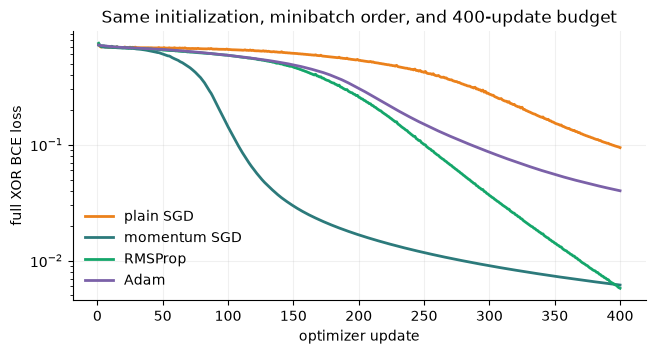

In [3]:
for name, result in results.items():
    plt.plot(np.arange(1, len(result['losses']) + 1), result['losses'],
             color=result['color'], lw=2, label=name)
plt.yscale('log'); plt.xlabel('optimizer update'); plt.ylabel('full XOR BCE loss')
plt.title('Same initialization, minibatch order, and 400-update budget')
plt.legend(frameon=False); plt.show()

## Final decision boundaries

Each panel evaluates the learned probability on the same dense grid. The boundary is the contour where $p(y=1\mid x)=0.5$. Different trajectories can reach different parameterizations of the same XOR rule.

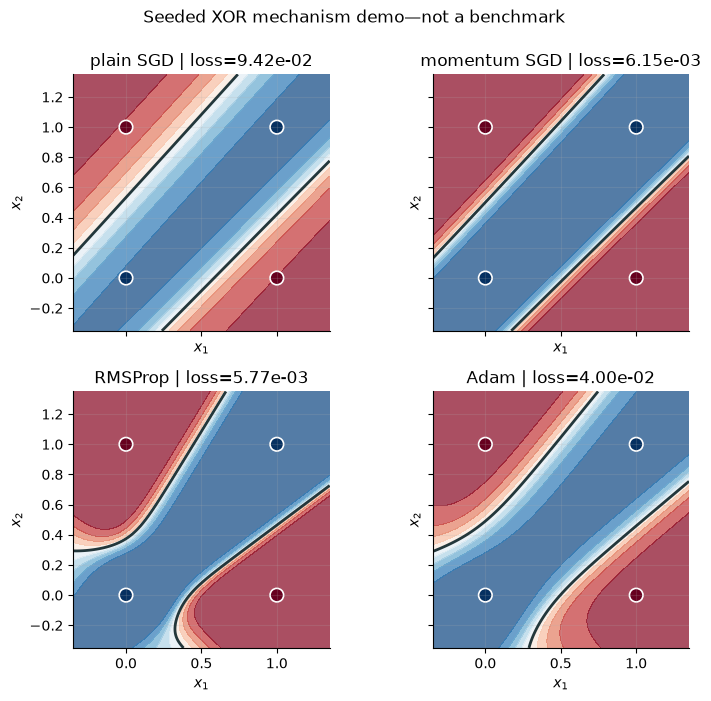

In [4]:
grid_axis = np.linspace(-.35, 1.35, 180)
G1, G2 = np.meshgrid(grid_axis, grid_axis)
grid = torch.tensor(np.column_stack([G1.ravel(), G2.ravel()]), dtype=torch.float32)

fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.0), sharex=True, sharey=True)
for ax, (name, result) in zip(axes.ravel(), results.items()):
    with torch.no_grad():
        probability_grid = torch.sigmoid(result['model'](grid).squeeze(-1)).reshape(G1.shape).numpy()
    ax.contourf(G1, G2, probability_grid, levels=np.linspace(0, 1, 11), cmap='RdBu_r', alpha=.72)
    ax.contour(G1, G2, probability_grid, levels=[.5], colors=INK, linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', vmin=0, vmax=1,
               s=95, edgecolor='white', linewidth=1.2)
    ax.set(title=f"{name} | loss={result['losses'][-1]:.2e}", xlabel='$x_1$', ylabel='$x_2$',
           xlim=(-.35, 1.35), ylim=(-.35, 1.35), aspect='equal')
fig.suptitle('Seeded XOR mechanism demo—not a benchmark', y=.995)
plt.tight_layout(); plt.show()

## Read the evidence carefully

- All four methods solved XOR under the documented settings.
- The curves do **not** establish a universal ranking: the learning rates were chosen per method, and this dataset has only four points.
- The control matters: changing initialization or minibatch order can change an optimizer trace even when the optimizer name stays fixed.
- The useful transfer is mechanistic: plain SGD uses the current gradient; momentum stores direction history; RMSProp stores squared-gradient scale; Adam stores both first- and second-moment histories.

Try one controlled change at a time: halve one learning rate, permute the batch schedule, or widen the hidden layer. Keep the other evidence fixed.